### PART 1: Environment Setup & Validation

#### 1.1 Installation

In [99]:
%pip install opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1.2 Import & Validate

In [100]:
import cv2
import matplotlib.pyplot as plt

In [101]:
print("opencc version:", cv2.__version__)
print("matplotlib is working:", plt.figure is not None)

opencc version: 4.13.0
matplotlib is working: True


### PART 2: Python Data Structures & Logic

#### Task 1: Object-Oriented Grocery Manager

In [102]:
class GroceryManager:
    def __init__(self):
        self.items = {}

    def add_item(self, item, quantity, price):
        self.items[item] = {'quantity': quantity, 'price': price}
        print(f"added: {item} (qty: {quantity}, price: {price})")

    def remove_item(self, item):
        if item in self.items:
            del self.items[item]
            print(f"removed: {item}")
        else:
            print(f"'{item}' not found in the grocery list.")

    def view_list(self):
        if not self.items:
            print("grocery list is empty.")
            return
        print(f"{'item':<15}{'quantity':<10}{'price':<10}")
        for item, details in self.items.items():
            print(f"{item:<15}{details['quantity']:<10}{details['price']:<10}")

    def calculate_total(self):
        total = sum(d['quantity'] * d['price'] for d in self.items.values())
        print(f"total cost: {total}")
        return total

In [103]:
manager = GroceryManager()
manager.add_item("apples", 4, 50)
manager.add_item("milk", 2, 120)
manager.add_item("bread", 1, 90)

manager.view_list()
manager.calculate_total()

manager.remove_item("milk")
manager.remove_item("eggs")  #trigger demo for error handling

manager.view_list()

added: apples (qty: 4, price: 50)
added: milk (qty: 2, price: 120)
added: bread (qty: 1, price: 90)
item           quantity  price     
apples         4         50        
milk           2         120       
bread          1         90        
total cost: 530
removed: milk
'eggs' not found in the grocery list.
item           quantity  price     
apples         4         50        
bread          1         90        


#### Task 2: Advanced Student Record System

In [104]:
students = {
    "S01": {"Name": "Areeba", "Major": "AI", "Grades": [85, 90, 78]},
    "S02": {"Name": "Emman", "Major": "CS", "Grades": [92, 88, 95]},
    "S03": {"Name": "Haris", "Major": "AI", "Grades": [70, 65, 80]},
    "S04": {"Name": "Huzaifa", "Major": "Data Sci", "Grades": [99, 94, 97]},
    "S05": {"Name": "Sabeeh", "Major": "CS", "Grades": [60, 72, 68]},
}

In [105]:
def top_student(records):
    best_name = None
    best_avg = -1
    for student_id, info in records.items():
        avg = sum(info["Grades"]) / len(info["Grades"])
        if avg > best_avg:
            best_avg = avg
            best_name = info["Name"]
    return best_name, best_avg

name, avg = top_student(students)
print(f"top student: {name} w/ avg grade {avg:.2f}")

top student: Huzaifa w/ avg grade 96.67


In [106]:
def students_by_major(records, major):
    found = [info["Name"] for info in records.values() if info["Major"] == major]
    if found:
        print(f"students in {major}: {', '.join(found)}")
    else:
        print(f"no students found in major: {major}")

students_by_major(students, "AI")
students_by_major(students, "CS")
students_by_major(students, "Philosophy")

students in AI: Areeba, Haris
students in CS: Emman, Sabeeh
no students found in major: Philosophy


### PART 3: Core cComputer Vision & Matplotlib

#### Task 3: Safe Image Loading & RGB Visualization

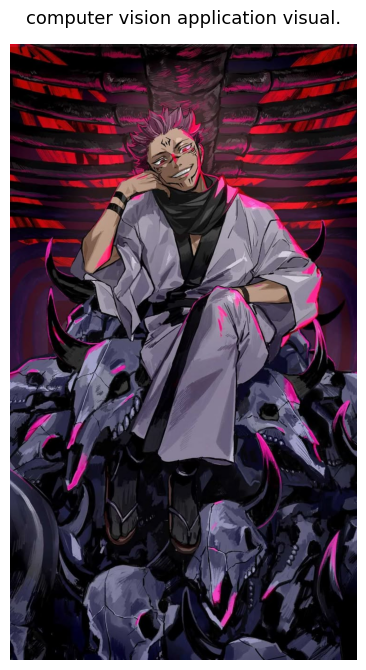

In [107]:
import cv2
import matplotlib.pyplot as plt

image_path = 'Sukuna.jpg'
image = cv2.imread(image_path)

if image is None:
    print("no image found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,8))
    plt.axis('off')
    plt.title("computer vision application visual.", fontsize=13, color='black', pad=15)
    plt.imshow(image_rgb)
    plt.show()

#### Task 4: Interactive Geometry & Blank Canvas

canvas center: (400, 400)


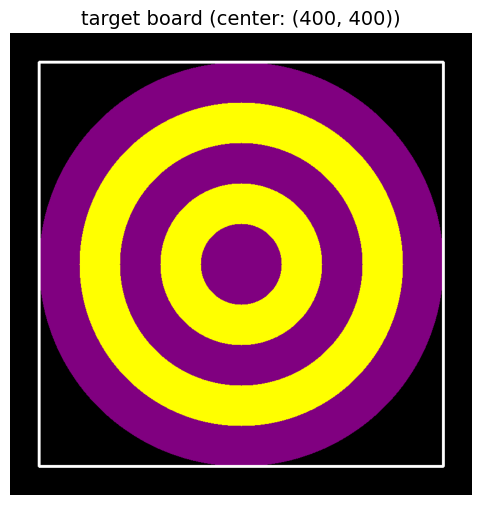

In [108]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

#800x800 blank canvas
canvas = np.zeros((800,800, 3), dtype=np.uint8)

#calculate exact center of the canvas
center_x, center_y = canvas.shape[1] // 2, canvas.shape[0] // 2
center = (center_x, center_y)
print(f"canvas center: {center}")

#5 alternating colors
colors = [
    (128, 0, 128),   # Purple
    (0, 255, 255),   # Yellow
    (128, 0, 128),   # Purple
    (0, 255, 255),   # Yellow
    (128, 0, 128)    # Purple
]

#drawing 5 concentric circles w/ increasing radius
max_radius = 350
num_circles = 5
step = max_radius // num_circles

for i in range(num_circles):
    radius = max_radius - (i * step)
    color = colors[i % len(colors)]
    cv2.circle(canvas, center, radius, color, thickness=-1)

#bounding box around outermost circle
top_left = (center_x - max_radius, center_y - max_radius)
bottom_right = (center_x + max_radius, center_y + max_radius)
cv2.rectangle(canvas, top_left, bottom_right, (255,255,255), thickness=3)

#converting from BGR to RGB
canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(canvas_rgb)
plt.title(f'target board (center: {center})', fontsize=14)
plt.axis('off')
plt.show()

### Task 5: Advanced Blurring & Numpy ROI Extraction

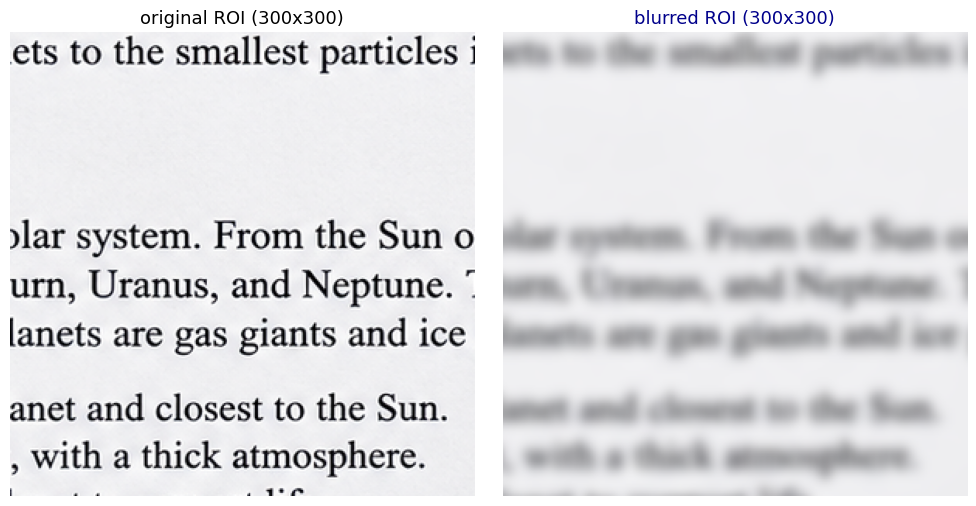

In [109]:
import cv2
import matplotlib.pyplot as plt

image_path = 'document.png'
image = cv2.imread(image_path)

if image is None:
    print("image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    #gaussian blur
    blurred_rgb = cv2.GaussianBlur(image_rgb, (25,25), 0)
    #get image dimensions
    height, width = image_rgb.shape[:2]
    center_y, center_x = height //2, width //2
    
    #300x300 ROI
    roi_size = 300
    half = roi_size // 2
    
    y_start, y_end = center_y - half, center_y + half
    x_start, x_end = center_x - half, center_x + half
    
    original_roi = image_rgb[y_start:y_end, x_start:x_end]
    blurred_roi = blurred_rgb[y_start:y_end, x_start:x_end]
    
    fig, axes = plt.subplots(1, 2, figsize=(10,5))
    axes[0].imshow(original_roi)
    axes[0].set_title('original ROI (300x300)', fontsize=13, color='black')
    axes[0].axis('off')

    axes[1].imshow(blurred_roi)
    axes[1].set_title('blurred ROI (300x300)', fontsize=13, color='darkblue')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

#### Task 6: Alpha Blending & Typography

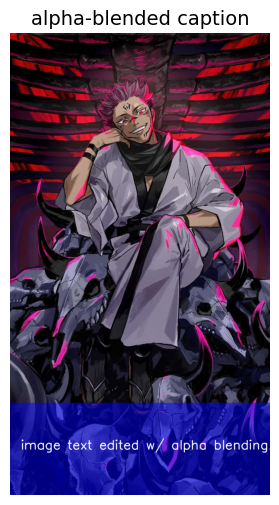

In [110]:
import cv2
import matplotlib.pyplot as plt

image_path = 'Sukuna.jpg'
image = cv2.imread(image_path)

if image is None:
    print("image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image_rgb.shape[:2]
    #overlay thats a copy of the og image
    overlay = image_rgb.copy()
    #bottom 20% region
    box_height = int(height * 0.20)
    y_start = height - box_height
    #solid blue rectangle over bottom 20% region
    cv2.rectangle(overlay, (0, y_start), (width, height), (0,0,255), thickness=-1)
    #blend overlay w/ og image
    alpha = 0.5
    blended = cv2.addWeighted(overlay, alpha, image_rgb, 1-alpha, 0)
    #title
    text = "image text edited w/ alpha blending."
    font = cv2.FONT_HERSHEY_SIMPLEX
    text_position = (30, height - box_height // 2)
    cv2.putText(blended, text, text_position, font, 1.2, (255, 255, 255), 2)

    plt.figure(figsize=(8, 6))
    plt.imshow(blended)
    plt.title('alpha-blended caption', fontsize=14)
    plt.axis('off')
    plt.show()

#### Task 7: Matrix-Based Rotation & Adaptive Thresholding

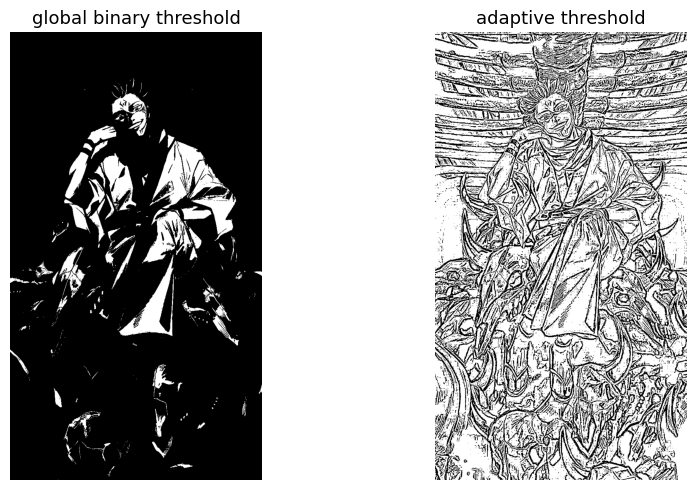

In [111]:
import cv2
import matplotlib.pyplot as plt

image_path = 'Sukuna.jpg'
image = cv2.imread(image_path)

if image is None:
    print("image not found.")
else:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    #global binary thresholding
    _, global_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    #adaptive thresholding - value calculated per local region
    adaptive_thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blockSize=11, C=2)
    #compare side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(global_thresh, cmap='gray')
    axes[0].set_title('global binary threshold', fontsize=13)
    axes[0].axis('off')
    axes[1].imshow(adaptive_thresh, cmap='gray')
    axes[1].set_title('adaptive threshold', fontsize=13)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

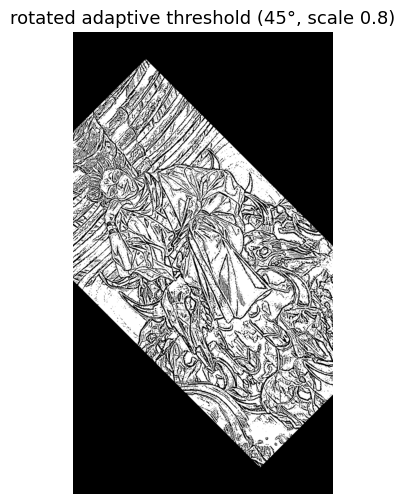

In [112]:
#rotate the adaptive threshold output by 45 degrees, scaled by 0.8
height, width = adaptive_thresh.shape[:2]
center = (width // 2, height // 2)

rotation_matrix = cv2.getRotationMatrix2D(center, 45, 0.8)
rotated_adaptive = cv2.warpAffine(adaptive_thresh, rotation_matrix, (width, height))

plt.figure(figsize=(6, 6))
plt.imshow(rotated_adaptive, cmap='gray')
plt.title('rotated adaptive threshold (45°, scale 0.8)', fontsize=13)
plt.axis('off')
plt.show()

#### Task 8: Masking with Bitwise Logic

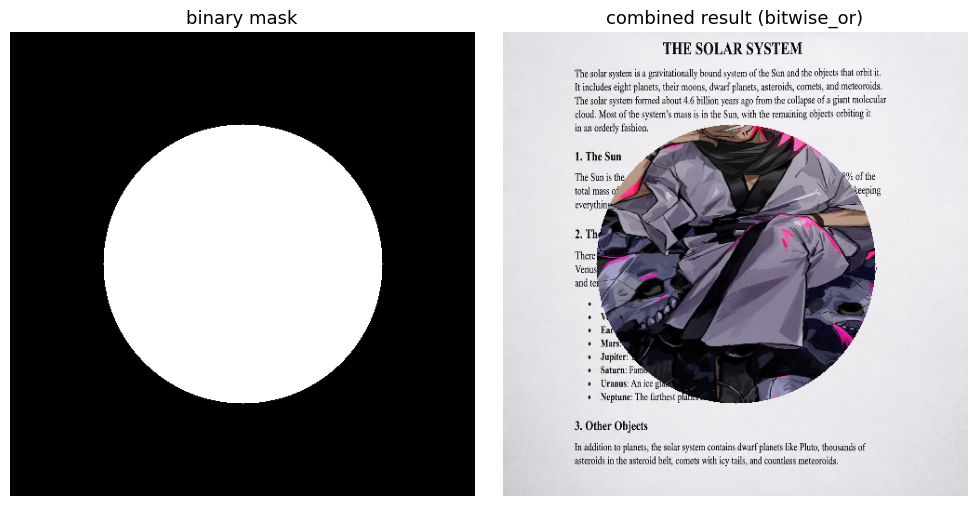

In [113]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image1 = cv2.imread('Sukuna.jpg')
image2 = cv2.imread('document.png')

if image1 is None or image2 is None:
    print("one or both images not found.")
else:
    #resize both imgs
    target_size = (500, 500)
    image1 = cv2.resize(image1, target_size)
    image2 = cv2.resize(image2, target_size)
    #creating a binary mask: black canvas w/ a thick white circle in the center
    mask = np.zeros((500, 500), dtype=np.uint8)
    center = (250, 250)
    radius = 150
    #filled white circle
    cv2.circle(mask, center, radius, 255, thickness=-1)  
    #bitwise_and to cut the circle shape OUT of image1 (foreground)
    foreground = cv2.bitwise_and(image1, image1, mask=mask)
    #inverting the mask, & using it to cut the bg (everything outside the circle) from image2
    inverse_mask = cv2.bitwise_not(mask)
    background = cv2.bitwise_and(image2, image2, mask=inverse_mask)
    #combine the two using bitwise_or
    combined = cv2.bitwise_or(foreground, background)
    combined_rgb = cv2.cvtColor(combined, cv2.COLOR_BGR2RGB)

    #final composited result
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(mask, cmap='gray')
    axes[0].set_title('binary mask', fontsize=13)
    axes[0].axis('off')
    axes[1].imshow(combined_rgb)
    axes[1].set_title('combined result (bitwise_or)', fontsize=13)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

#### Task 9: Statistical Image Profiling With Pandas

In [114]:
import cv2
import pandas as pd

image_path = 'Sukuna.jpg'
image = cv2.imread(image_path)

if image is None:
    print("image not found.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    #split into individual channels & flatten each 2D channel into a 1D array
    red_channel = image_rgb[:, :, 0].flatten()
    green_channel = image_rgb[:, :, 1].flatten()
    blue_channel = image_rgb[:, :, 2].flatten()

    #load the three 1D arrays into a pandas df
    pixel_df = pd.DataFrame({
        'Red': red_channel,
        'Green': green_channel,
        'Blue': blue_channel
    })

    print("statistical summary of image pixel vals:")
    print(pixel_df.describe())

statistical summary of image pixel vals:
                 Red          Green           Blue
count  962688.000000  962688.000000  962688.000000
mean       62.254509      43.028329      59.153653
std        57.079978      45.148926      51.964860
min         0.000000       0.000000       0.000000
25%        13.000000       7.000000      16.000000
50%        47.000000      26.000000      43.000000
75%        96.000000      68.000000      95.000000
max       255.000000     255.000000     255.000000
